In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import scipy.stats as sts
import matplotlib.pyplot as plt

In [2]:
df_users = pd.read_csv('acc-data/ACC-usagers-2018.csv')
df_vroom = pd.read_csv('acc-data/ACC-vehicules-2018.csv')

In [3]:
merged = df_users.merge(df_vroom,"inner","Num_Acc")
merged

,Num_Acc,place,catu,grav,sexe,trajet,secu,locp,actp,etatp,an_nais,num_veh_x,senc,catv,occutc,obs,obsm,choc,manv,num_veh_y
0,201800000001,1.0,1,3,1,0.0,11.0,0.0,0.0,0.0,1928.0,B01,0.0,7,0,0.0,2.0,3.0,1.0,B01
1,201800000001,1.0,1,3,1,0.0,11.0,0.0,0.0,0.0,1928.0,B01,0.0,7,0,0.0,2.0,2.0,15.0,A01
2,201800000001,1.0,1,1,1,5.0,11.0,0.0,0.0,0.0,1960.0,A01,0.0,7,0,0.0,2.0,3.0,1.0,B01
3,201800000001,1.0,1,1,1,5.0,11.0,0.0,0.0,0.0,1960.0,A01,0.0,7,0,0.0,2.0,2.0,15.0,A01
4,201800000002,1.0,1,1,1,0.0,11.0,0.0,0.0,0.0,1947.0,A01,0.0,7,0,0.0,1.0,0.0,1.0,A01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248401,201800057782,1.0,1,4,1,9.0,21.0,NaN,NaN,NaN,1974.0,B01,2.0,31,0,0.0,2.0,1.0,0.0,B01
248402,201800057783,1.0,1,4,1,9.0,11.0,NaN,NaN,NaN,1973.0,B01,2.0,10,0,0.0,2.0,1.0,0.0,B01
248403,201800057783,1.0,1,4,1,9.0,11.0,NaN,NaN,NaN,1973.0,B01,1.0,10,0,0.0,2.0,0.0,0.0,A01
248404,201800057783,1.0,1,4,2,9.0,11.0,NaN,NaN,NaN,1990.0,A01,2.0,10,0,0.0,2.0,1.0,0.0,B01


In [4]:
df_anova = merged[["Num_Acc","catv","grav","trajet","secu"]]
df_anova

,Num_Acc,catv,grav,trajet,secu
0,201800000001,7,3,0.0,11.0
1,201800000001,7,3,0.0,11.0
2,201800000001,7,1,5.0,11.0
3,201800000001,7,1,5.0,11.0
4,201800000002,7,1,0.0,11.0
...,...,...,...,...,...
248401,201800057782,31,4,9.0,21.0
248402,201800057783,10,4,9.0,11.0
248403,201800057783,10,4,9.0,11.0
248404,201800057783,10,4,9.0,11.0


REARRANGE SO THAT SEVERITY IS FROM BEST TO WORST

In [5]:
def change(x):
    if x == 2:
        return 4
    if x == 4:
        return 2
    if x == 1:
        return 1 
    if x == 3:
        return 3

In [6]:
df_anova["grav2"] = df_anova["grav"].map(change)
df_anova

,Num_Acc,catv,grav,trajet,secu,grav2
0,201800000001,7,3,0.0,11.0,3
1,201800000001,7,3,0.0,11.0,3
2,201800000001,7,1,5.0,11.0,1
3,201800000001,7,1,5.0,11.0,1
4,201800000002,7,1,0.0,11.0,1
...,...,...,...,...,...,...
248401,201800057782,31,4,9.0,21.0,2
248402,201800057783,10,4,9.0,11.0,2
248403,201800057783,10,4,9.0,11.0,2
248404,201800057783,10,4,9.0,11.0,2


C:\Users\salva\AppData\Local\Temp\ipykernel_35144\2039511842.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_anova, x="catv", y="grav2", ax=ax , palette='rainbow')


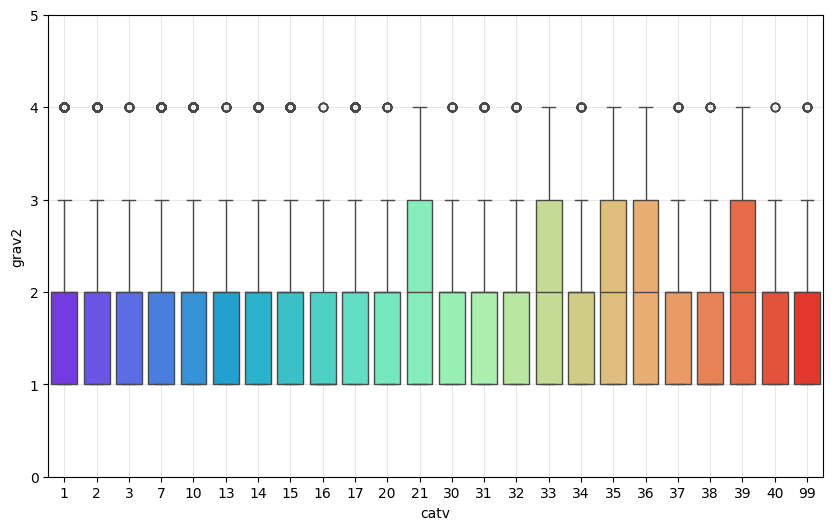

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid()


sns.boxplot(data=df_anova, x="catv", y="grav2", ax=ax , palette='rainbow')
ax.set_ybound(0,5)
ax.grid(True,alpha=0.3)




31 - Motocyclette > 50 cm3 et <= 125 cm3 

33 - Motocyclette > 125 cm3

35 - Quad léger <= 50 cm3 (Quadricycle à moteur non carrossé)

36 - Quad lourd > 50 cm3 (Quadricycle à moteur non carrossé)

39 - Train

Those are the ones where the sccidents seem to be of higher severity. 

# For Lyon & Paris

In [8]:
df_acc = pd.read_csv("acc-data/ACC-caracteristiques-2018.csv")

In [9]:
merged = merged.merge(df_acc,'inner',on="Num_Acc")
merged

,Num_Acc,place,catu,grav,sexe,trajet,secu,locp,actp,etatp,...,agg,int,atm,col,com,adr,gps,lat,long,dep
0,201800000001,1.0,1,3,1,0.0,11.0,0.0,0.0,0.0,...,1,4,1.0,1.0,5,route des Ansereuilles,M,5055737.0,294992.0,590
1,201800000001,1.0,1,3,1,0.0,11.0,0.0,0.0,0.0,...,1,4,1.0,1.0,5,route des Ansereuilles,M,5055737.0,294992.0,590
2,201800000001,1.0,1,1,1,5.0,11.0,0.0,0.0,0.0,...,1,4,1.0,1.0,5,route des Ansereuilles,M,5055737.0,294992.0,590
3,201800000001,1.0,1,1,1,5.0,11.0,0.0,0.0,0.0,...,1,4,1.0,1.0,5,route des Ansereuilles,M,5055737.0,294992.0,590
4,201800000002,1.0,1,1,1,0.0,11.0,0.0,0.0,0.0,...,2,7,7.0,7.0,11,Place du général de Gaul,M,5052936.0,293151.0,590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248401,201800057782,1.0,1,4,1,9.0,21.0,NaN,NaN,NaN,...,2,1,1.0,1.0,611,cavani-Kavani sud ( rue,Y,1278622.0,4522036.0,976
248402,201800057783,1.0,1,4,1,9.0,11.0,NaN,NaN,NaN,...,2,1,1.0,1.0,611,m'tsapere-Nationale 2 (r,Y,1278943.0,4522408.0,976
248403,201800057783,1.0,1,4,1,9.0,11.0,NaN,NaN,NaN,...,2,1,1.0,1.0,611,m'tsapere-Nationale 2 (r,Y,1278943.0,4522408.0,976
248404,201800057783,1.0,1,4,2,9.0,11.0,NaN,NaN,NaN,...,2,1,1.0,1.0,611,m'tsapere-Nationale 2 (r,Y,1278943.0,4522408.0,976


In [10]:
df_anova2 = merged[["Num_Acc","grav","dep","trajet","catv"]]
df_anova2

,Num_Acc,grav,dep,trajet,catv
0,201800000001,3,590,0.0,7
1,201800000001,3,590,0.0,7
2,201800000001,1,590,5.0,7
3,201800000001,1,590,5.0,7
4,201800000002,1,590,0.0,7
...,...,...,...,...,...
248401,201800057782,4,976,9.0,31
248402,201800057783,4,976,9.0,10
248403,201800057783,4,976,9.0,10
248404,201800057783,4,976,9.0,10


In [11]:
df_anova2["grav2"] = df_anova2["grav"].map(change)

Lyon_anova = df_anova2[df_anova2["dep"] == 690]
Paris_anova = df_anova2[df_anova2["dep"] == 750]

C:\Users\salva\AppData\Local\Temp\ipykernel_35144\824232982.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=Lyon_anova, x="catv", y="grav2", ax=ax , palette='rainbow')


Text(0.5, 1.0, 'Severity of accident by vehicle category in Lyon')

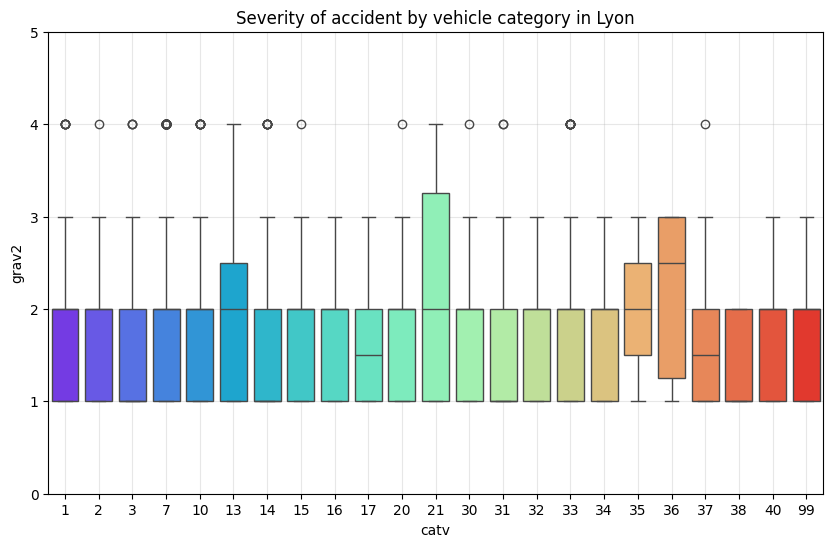

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=Lyon_anova, x="catv", y="grav2", ax=ax , palette='rainbow')
ax.set_ybound(0,5)
ax.grid(True,alpha=0.3)
ax.set_title("Severity of accident by vehicle category in Lyon")

C:\Users\salva\AppData\Local\Temp\ipykernel_35144\1207126098.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=Paris_anova, x="catv", y="grav2", ax=ax , palette='rainbow')


Text(0.5, 1.0, 'Severity of accident by vehicle category in Paris')

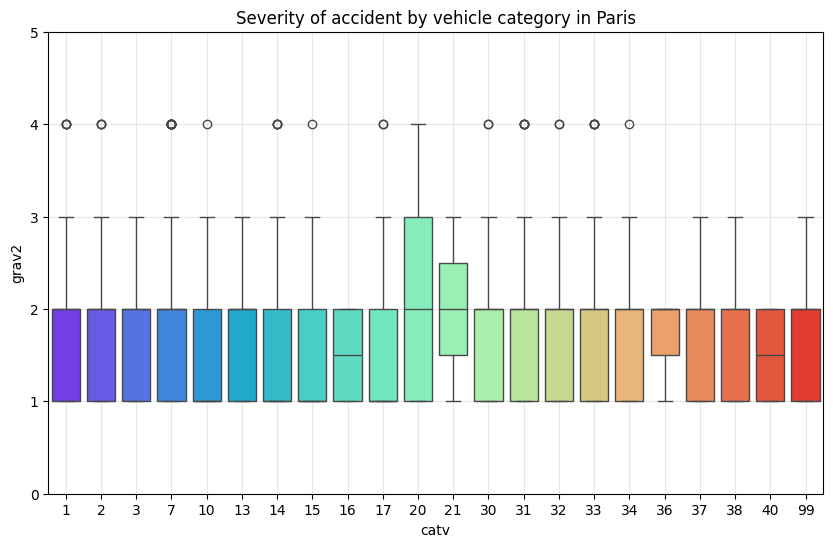

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))


sns.boxplot(data=Paris_anova, x="catv", y="grav2", ax=ax , palette='rainbow')
ax.set_ybound(0,5)
ax.grid(True,alpha=0.3)
ax.set_title("Severity of accident by vehicle category in Paris")

What we are going to do is calculate the percentage of severe accidents by category 

In [14]:
by_cat = Lyon_anova.groupby("catv")["Num_Acc"].size()
by_cat = by_cat.reset_index()
by_cat


by_cat2 = Paris_anova.groupby("catv")["Num_Acc"].size()
by_cat2 = by_cat2.reset_index()
by_cat

,catv,Num_Acc
0,1,535
1,2,190
2,3,94
3,7,6923
4,10,907
5,13,35
6,14,63
7,15,75
8,16,5
9,17,84


In [15]:
severe_lyon = Lyon_anova[(Lyon_anova["grav"] == 2) | (Lyon_anova["grav"] == 3)]
severe_lyon_cat = severe_lyon.groupby("catv")["Num_Acc"].size()
severe_lyon_cat = severe_lyon_cat.reset_index()


severe_Paris = Paris_anova[(Paris_anova["grav"] == 2) | (Paris_anova["grav"] == 3)]
severe_Paris_cat = severe_Paris.groupby("catv")["Num_Acc"].size()
severe_Paris_cat = severe_Paris_cat.reset_index()

In [16]:
severe_lyon_cat["per"] = severe_lyon_cat["Num_Acc"] / by_cat["Num_Acc"]
severe_Paris_cat["per"] = severe_Paris_cat["Num_Acc"] / by_cat2["Num_Acc"]

severe_Paris_cat

#severe_lyon_cat = severe_lyon_cat.where(severe_lyon_cat["per"] > 100 ,100)
severe_lyon_cat

,catv,Num_Acc,per
0,1,59,0.110280
1,2,33,0.173684
2,3,9,0.095745
3,7,714,0.103134
4,10,87,0.095921
5,13,9,0.257143
6,14,10,0.158730
7,15,9,0.120000
8,16,1,0.200000
9,17,6,0.071429


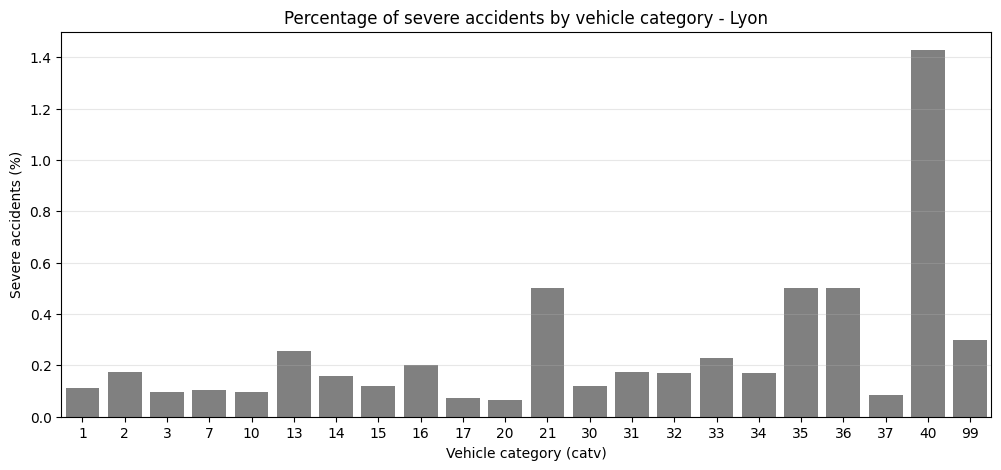

In [17]:
plt.figure(figsize=(12, 5))
sns.barplot(data=severe_lyon_cat, x="catv", y="per", color="gray")
plt.xlabel("Vehicle category (catv)")
plt.ylabel("Severe accidents (%)")
plt.title("Percentage of severe accidents by vehicle category - Lyon")
plt.grid(axis="y", alpha=0.3)

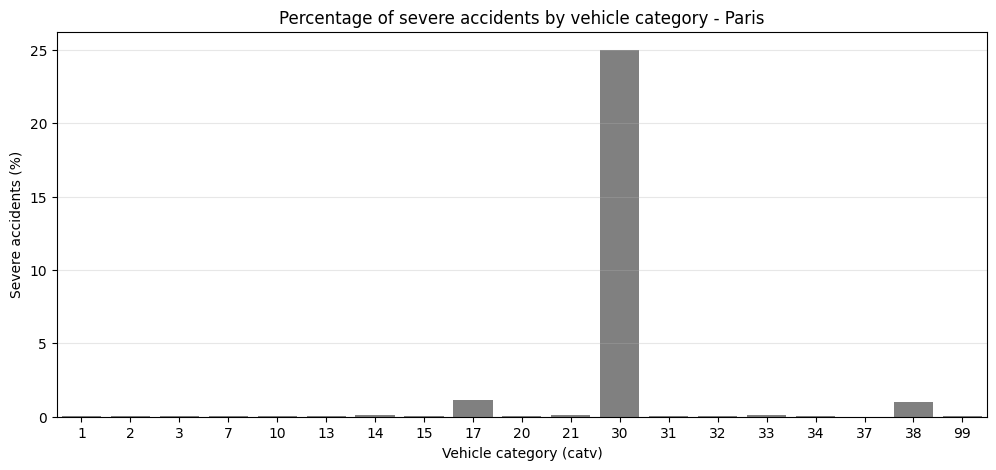

In [18]:
plt.figure(figsize=(12, 5))
sns.barplot(data=severe_Paris_cat, x="catv", y="per", color="gray")
plt.xlabel("Vehicle category (catv)")
plt.ylabel("Severe accidents (%)")
plt.title("Percentage of severe accidents by vehicle category - Paris")
plt.grid(axis="y", alpha=0.3)